### High-level setup

In [1]:
USE_COLAB = False     ## Set to False if running in a personal workstation
FFD_SCALE = 3.0       ## Switch between 1.0/3.0/5.0
MI_ESTIMATOR = "DC"   ## Switch between JSD/DC/DV
DISCREPANCY = "JSD"   ## Do not change this option
USE_CUDA = False #True       ## Switch to True if running in Colab or Workstation with GPU
NDE_NET = 'MAF'       ## Select between MAF and NDN

### Run it in case of using Colab servers

In [2]:
import sys
from google.colab import drive
!rm -rf LiFIMI_Attack
!git clone https://github.com/Vegnics/LiFIMI_Attack.git
sys.path.append("./LiFIMI_Attack")
DIR = 'results/FFD'
#drive.mount('/content/drive')
#!cp -r /content/drive/MyDrive/SimpleFace ./
#IMG_FOLDER = "/content/SimpleFace"
#OUT_FOLDER = "/content/out_folder"

Cloning into 'LiFIMI_Attack'...
remote: Enumerating objects: 641, done.
remote: Counting objects: 100% (246/246), done.
remote: Compressing objects: 100% (172/172), done.
remote: Total 641 (delta 154), reused 153 (delta 72), pack-reused 395 (from 1)
Receiving objects: 100% (641/641), 16.77 MiB | 16.65 MiB/s, done.
Resolving deltas: 100% (397/397), done.


### Import the required modules

In [2]:
import os, sys, inspect, time
"""
solve the conflict between paths, and work dir
"""
sys.path.append('../')
##os.chdir('../')
print(sys.path)
print(os.getcwd())

import numpy as np
import torch
import matplotlib.pyplot as plt
torch.multiprocessing.set_sharing_strategy('file_system')

import lfi
from lfi.utils import discrepancy, visualization
from lfi.algorithms import ABC_algorithms, SMCABC, SMC2ABC, SNLABC, SNL2ABC
from lfi.detsimul import problem_FFD,problem_FFD_image
from lfi.utils import uos, umath

['/home/amaranth2/miniconda3/envs/itcff/lib/python311.zip', '/home/amaranth2/miniconda3/envs/itcff/lib/python3.11', '/home/amaranth2/miniconda3/envs/itcff/lib/python3.11/lib-dynload', '', '/home/amaranth2/miniconda3/envs/itcff/lib/python3.11/site-packages', '../']
/home/amaranth2/ITC_FF/examples


ImportError: cannot import name 'ISN_img' from partially initialized module 'lfi.statnet.statnets' (most likely due to a circular import) (/home/amaranth2/ITC_FF/examples/../lfi/statnet/statnets.py)

### FFD Image problem definition

/content/LiFIMI_Attack/images_test/ledecky_front.jpg
/content/LiFIMI_Attack/images_test/pacquiao_front.jpg
[True posterior] pilot run 
finished pilot run: 500
finished pilot run: 1000
finished pilot run: 1500
finished pilot run: 2000
finished pilot run: 2500
finished pilot run: 3000
finished pilot run: 3500
finished pilot run: 4000
finished pilot run: 4500
finished pilot run: 5000
finished pilot run: 5500
finished pilot run: 6000
finished pilot run: 6500
finished pilot run: 7000
finished pilot run: 7500
finished pilot run: 8000
finished pilot run: 8500
finished pilot run: 9000
finished pilot run: 9500
finished pilot run: 10000
finished pilot run: 10500
finished pilot run: 11000
finished pilot run: 11500
finished pilot run: 12000
finished pilot run: 12500
finished pilot run: 13000
finished pilot run: 13500
finished pilot run: 14000
finished pilot run: 14500
finished pilot run: 15000
finished pilot run: 15500
finished pilot run: 16000
finished pilot run: 16500
finished pilot run: 17000
f

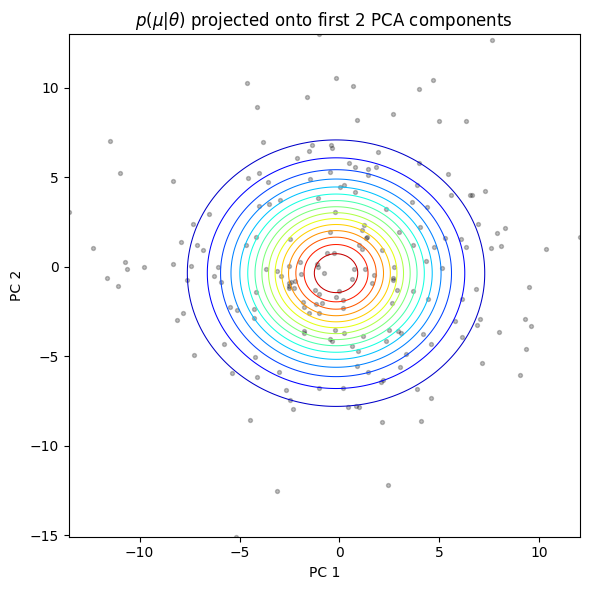

mean-parma1 =  0.01476750359357538      mean-param2 =  10.688912011002838


<Figure size 500x400 with 0 Axes>

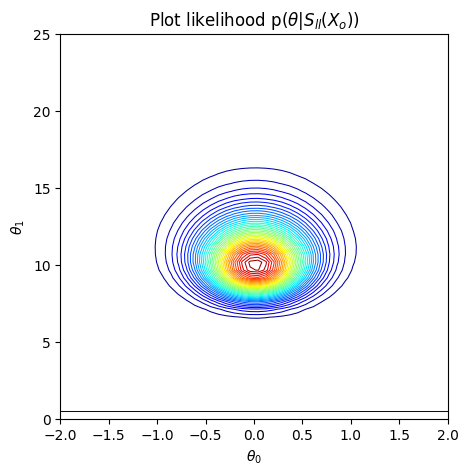

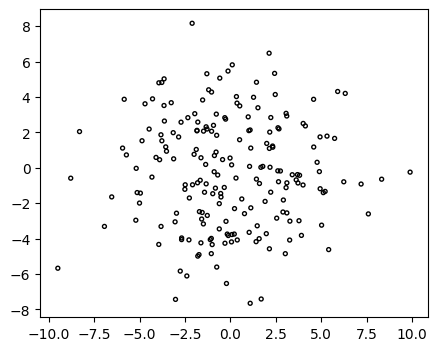

In [4]:
DIR = 'results/FFD'
#IMG_FOLDER = "/home/amaranth2/Downloads/SimpleFace"
IMG_FOLDER = "/content/LiFIMI_Attack/images_test"
OUT_FOLDER = "/home/quinoa/out_folder"
problem = problem_FFD_image.FFD_Image_Problem(N=500, n=200)
problem.img_folder = IMG_FOLDER
problem.out_img_folder = OUT_FOLDER
problem.true_mean = 0.0
problem.true_var = 10.0
problem.get_work_imgs()

true_theta = problem.get_true_theta()
## FFD parameter scale
problem.ffd_scale = FFD_SCALE

## The simulator returns the observed mu params and
## the deformed images
problem.data_obs, problem.imgs_obs = problem.simulator(true_theta)
## Compute PCA over the observed data
problem.compute_pca(n_components=15)
## Pick a mu param
#problem.y_obs, problem.imgs_obs = problem.statistics(data=problem.data_obs,images=problem.imgs_obs, theta=true_theta)
problem.y_obs, _ = problem.statistics(data=problem.data_obs,images=problem.imgs_obs, theta=true_theta)

## Sample thetas from the true posterior
true_samples = problem.sample_from_true_posterior()
## Get the true theta
theta_true = problem.get_true_theta()

## Visualize the likelihood of the samples p(x|theta)
problem.visualize()
plt.figure(figsize=(5,4))
Xs, Ys, Zs = visualization.plot_likelihood(samples=true_samples,
                              log_likelihood_function=problem.log_likelihood,
                              dimensions=(0,1),
                              bounded = False,
                              return_data=True,
                              xmin = -2.0,
                              xmax = 2.0,
                              ymin = 0.0,
                              ymax = 25.0)
np.save(f"Xs_gt_nde_{NDE_NET}_mi_{MI_ESTIMATOR}_scale_{FFD_SCALE}.npy", Xs)
np.save(f"Ys_gt_{NDE_NET}_mi_{MI_ESTIMATOR}_scale_{FFD_SCALE}.npy", Ys)
np.save(f"Zs_gt_{NDE_NET}_mi_{MI_ESTIMATOR}_scale_{FFD_SCALE}.npy", Zs)
plt.show()
visualization.plot_samples(problem.data_obs)
#uos.save_object(DIR, 'true_samples', true_samples)

### Visualize warped images

Plotting original images


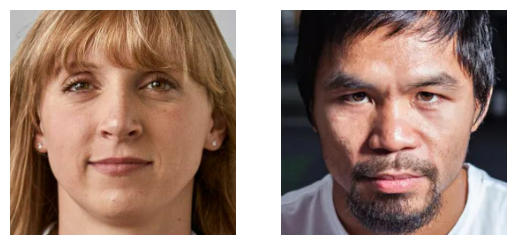

Plotting warped images


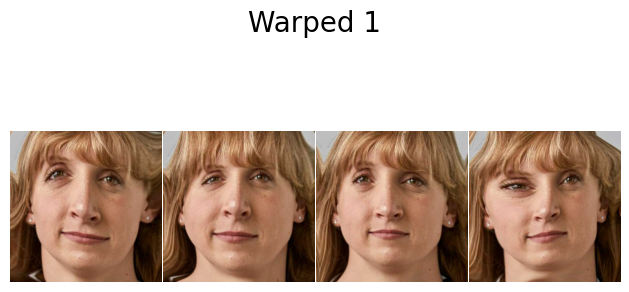

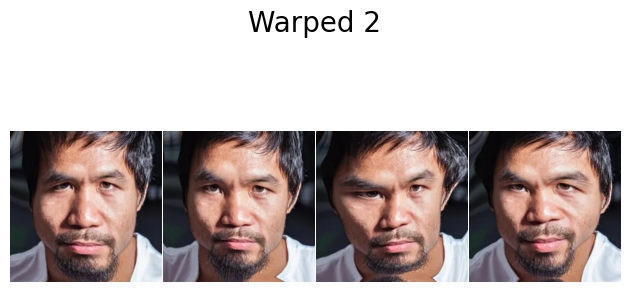

In [5]:
# Original images
print("Plotting original images")
figs,axes = plt.subplots(1,len(problem.work_imgs))
for k,img in enumerate(problem.work_imgs):
    axes[k].imshow(img[:,:,::-1])
    axes[k].set_axis_off()
plt.show()

print("Plotting warped images")
imgs = problem.imgs_obs
imgs_1 = imgs[0:4]
figs,axes = plt.subplots(1,4)
figs.suptitle('Warped 1', fontsize=20, y=0.92)
#figs.tight_layout(rect=[0, 0, 1, 0.9])
for i in range(4):
    axes[i].imshow(imgs_1[i][:,:,::-1])
    axes[i].set_axis_off()
figs.tight_layout()
plt.subplots_adjust(top=0.99,wspace=0.01)
plt.show()

imgs_2 = imgs[imgs.shape[0]//2+1:imgs.shape[0]//2+5]
figs,axes = plt.subplots(1,4)
figs.suptitle('Warped 2', fontsize=20, y=0.92)
#plt.tight_layout()
for i in range(4):
    axes[i].imshow(imgs_2[i][:,:,::-1])
    axes[i].set_axis_off()
figs.tight_layout()
plt.subplots_adjust(top=0.99,wspace=0.01)
plt.show()

### Run the SNL-StatNet algorithm (up to 10 iterations)

In [ ]:
## Sequential Neural Likelihood
hyperparams = ABC_algorithms.Hyperparams()
hyperparams.save_dir = DIR
hyperparams.device = 'cuda:0' if USE_CUDA else 'cpu'
hyperparams.num_sim = 2200 #4000                   # number of sampling/simulation rounds
hyperparams.L = 10                                # number of learning rounds
hyperparams.type = 'cnnimg'
hyperparams.stat = 'infomax'                     # statistics function: infomax/moment/score

#Hyperparameters for StatNet
hyperparams.n_neg = 3
hyperparams.bs = 32
hyperparams.lr = 5.0e-4

hyperparams.estimator = MI_ESTIMATOR                     # MI estimator; JSD (accurate) or DC (fast)
hyperparams.nde = NDE_NET                         # nde; MAF (D>1) or MDN (D=1)
from lfi.utils import discrepancy, visualization

print('\n SNL ABC')
print(f"Imgs observed: {problem.imgs_obs.shape}")
problem.n = 2 # Number of image simulations (only one is chosen)
snl_abc = SNL2ABC.SNL2_ABC_Image(problem, discrepancy=discrepancy.eculidean_dist, hyperparams=hyperparams)
snl_abc.sample_keep = 400
snl_abc.run()

JSD_array = []
for l in range(len(snl_abc.nde_array)):
    print('Iteration: ', l+1)
    snl_abc.nde_net = snl_abc.nde_array[l]
    Xs, Ys, Zs = visualization.plot_likelihood(samples=true_samples,
                                               log_likelihood_function=snl_abc.log_likelihood,
                                               dimensions=(0,1),
                                               bounded=False,
                                               return_data=True,
                                               xmin = -2.0,
                                               xmax = 2.0,
                                               ymin = 0.0,
                                               ymax = 25.0)
    np.save(f"Xs_iter{l}_{NDE_NET}_mi_{MI_ESTIMATOR}_scale_{FFD_SCALE}.npy", Xs)
    np.save(f"Ys_iter{l}_{NDE_NET}_mi_{MI_ESTIMATOR}_scale_{FFD_SCALE}.npy", Ys)
    np.save(f"Zs_iter{l}_{NDE_NET}_mi_{MI_ESTIMATOR}_scale_{FFD_SCALE}.npy", Zs)
    plt.show()
    JSD = discrepancy.JSD(problem.log_likelihood, snl_abc.log_likelihood, true_samples, true_samples, N_grid=30)
    JSD_array.append(JSD)
    print('JSD snl = ', JSD)
#uos.save_object(DIR, 'JSD_SNL', JSD_array)


 SNL ABC
Imgs observed: (400, 256, 256, 3)
iteration  0
[sampling] finished sampling  22
[sampling] finished sampling  44
[sampling] finished sampling  66
[sampling] finished sampling  88
Rejection Sampling 100, theta: [ 3.42024572 68.6693235 ]
[sampling] finished sampling  110
[sampling] finished sampling  132
[sampling] finished sampling  154
[sampling] finished sampling  176
[sampling] finished sampling  198
Rejection Sampling 200, theta: [ 4.6197599  25.42381216]

 > fitting encoder
learn stat, all_stats: torch.Size([220, 256, 256, 3])
summary statistic dim = 4 original dim = 72
architecture [72, 100, 100, 4]
Out front end: 100
Out front end: 100
Optimizer max_iter: 2000
finished: t= 0 loss= -0.5634704232215881 loss val= -0.4324743449687958 best loss -0.4324743449687958
finished: t= 200 loss= -0.9985291361808777 loss val= -0.7226904034614563 best loss -0.8222566246986389
finished: t= 400 loss= -0.9996188879013062 loss val= -0.7009779214859009 best loss -0.8222566246986389
finished

Iteration:  1
mean-parma1 =  -0.0088863012413693      mean-param2 =  10.91216543841842


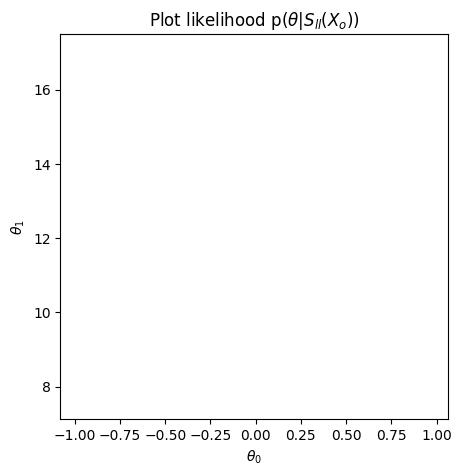

/content/LiFIMI_Attack/lfi/utils/discrepancy.py:171: RuntimeWarning: invalid value encountered in divide
  prob_q = prob_q/sum(prob_q)


JSD snl =  [nan]
Iteration:  2
mean-parma1 =  -0.0088863012413693      mean-param2 =  10.91216543841842


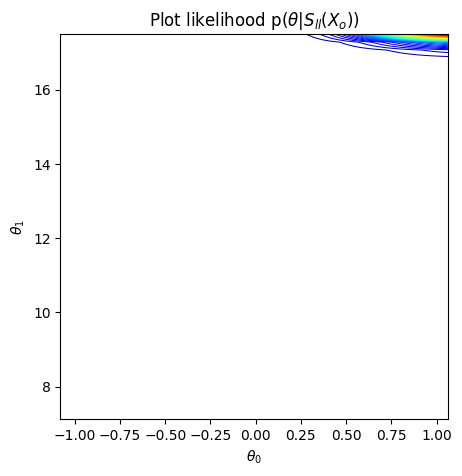

JSD snl =  [0.68925324]
Iteration:  3
mean-parma1 =  -0.0088863012413693      mean-param2 =  10.91216543841842


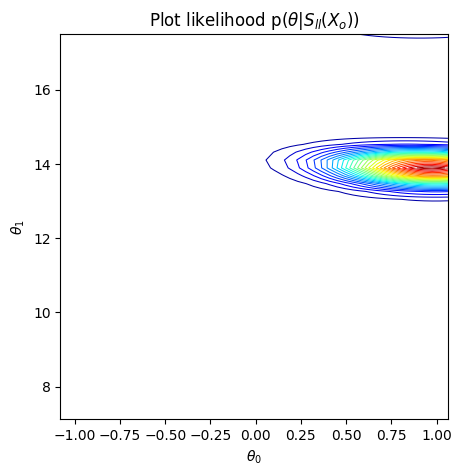

JSD snl =  [0.6227722]
Iteration:  4
mean-parma1 =  -0.0088863012413693      mean-param2 =  10.91216543841842


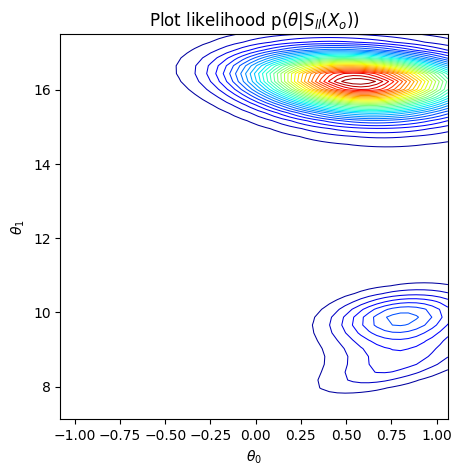

JSD snl =  [0.57079269]
Iteration:  5
mean-parma1 =  -0.0088863012413693      mean-param2 =  10.91216543841842


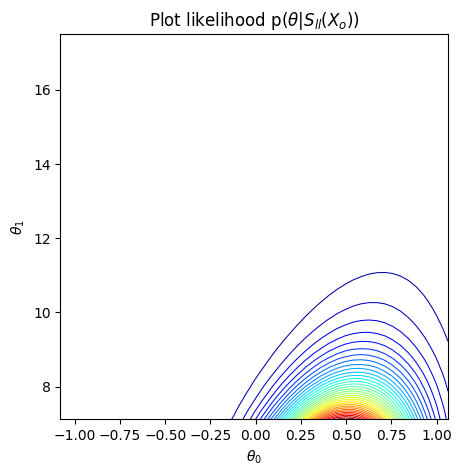

JSD snl =  [0.50716396]


In [ ]:
JSD_array = []
for l in range(len(snl_abc.nde_array)):
    print('Iteration: ', l+1)
    snl_abc.nde_net = snl_abc.nde_array[l]
    Xs, Ys, Zs = visualization.plot_likelihood(samples=true_samples,
                                               log_likelihood_function=snl_abc.log_likelihood,
                                               dimensions=(0,1),
                                               bounded=False,
                                               return_data=True)
    np.save(f"Xs_iter{l}.npy", Xs)
    np.save(f"Ys_iter{l}.npy", Ys)
    np.save(f"Zs_iter{l}.npy", Zs)
    plt.show()
    JSD = discrepancy.JSD(problem.log_likelihood, snl_abc.log_likelihood, true_samples, true_samples, N_grid=30)
    JSD_array.append(JSD)
    print('JSD snl = ', JSD)